# Baseline CNN — CIFAR-10
**Thesis:** Curriculum-Style Augmentation for Image Classification

This notebook runs your baseline experiments:
- Experiment 1: No augmentation (floor)
- Experiment 2: Static augmentation (main baseline)


In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — go to Runtime → Change runtime type → T4 GPU')

Device: cpu
No GPU — go to Runtime → Change runtime type → T4 GPU


In [8]:
CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoints will save to: {CHECKPOINT_DIR}")

Checkpoints will save to: ./checkpoints


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import time
from pathlib import Path

In [21]:
# ── Reproducibility ─────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [9]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [12]:
if device.type == "mps":
    torch.set_float32_matmul_precision("high")

In [13]:
# ── Data loader factory ─────────────────────────────────────
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

def get_loaders(augmentation='static', batch_size=128, debug=False):
    if augmentation == 'none':
        train_transform = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
    elif augmentation == 'static':
        train_transform = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2, hue=0.1),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])

    test_transform = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])

    full_train = datasets.CIFAR10('./data', train=True,  download=True,
                                  transform=train_transform)
    testset    = datasets.CIFAR10('./data', train=False, download=True,
                                  transform=test_transform)

    val_size   = int(len(full_train) * 0.1)
    train_size = len(full_train) - val_size
    train_ds, val_ds = random_split(full_train, [train_size, val_size],
                                     generator=torch.Generator().manual_seed(42))

    if debug:
        train_ds = torch.utils.data.Subset(train_ds, range(512))
        val_ds   = torch.utils.data.Subset(val_ds,   range(128))
        testset  = torch.utils.data.Subset(testset,  range(128))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=True)
    test_loader  = DataLoader(testset,  batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=True)

    print(f'✅ Data loaded | Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(testset):,}')
    return train_loader, val_loader, test_loader

Gradient Descent update rule:
$$
\theta_{t+1} = \theta_t - \eta \nabla J(\theta_t)
$$

Adam: Combines momentum (past gradients) and adaptive learning rates (based on squared gradients).

$$
\theta_t = \theta_{t-1} - \eta \cdot \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

In [ ]:
# Define  (Model + Data + Training)
# ── Model
class CIFAR10_Baseline(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  16, kernel_size=3, padding=1), nn.BatchNorm2d(16),  nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 32x32 → 16x16
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 16x16 → 8x8
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 8x8 → 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(1024, 512),          nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)

# Resnet-18 model
from torchvision.models import resnet18
class Resnet18_Baseline(nn.Module):
    """
    Resnet-18 baseline for CIFAR-10.

    Architecture:
        Block 1: Conv(3→16) → BN → ReLU → Conv(16→32) → BN → ReLU → MaxPool
        Block 2: Conv(32→64) → BN → ReLU → Conv(64→128) → BN → ReLU → MaxPool
        Block 3: Conv(128→256) → BN → ReLU → Conv(256→256) → BN → ReLU → MaxPool
        Head:    Flatten → FC(4096→1024) → ReLU → Dropout(0.5) → FC(1024→512) → ReLU → FC(512→10)

    Input:  (B, 3, 32, 32)
    Output: (B, 10)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.backbone = resnet18(weights=None)

        self.backbone.conv1 = nn.Conv2d(
            in_channels = 3,
            out_channels = 64,
            kernel_size = 3,
            stride=1,
            padding=1,
            bias=False
        )
        self.backbone.maxpool = nn.Identity()
        self.backbone.fc      = nn.Linear(512, num_classes)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

# Optimizers Factory
def build_optimizer(model, optimizer_name='sgd', lr=None, weight_decay=5e-4):
  """
  Build an optimizer for the given model.
  Returns (optimizer, default_lr).
  Adam : lr = 0.001
  SGD  : lr = 0.1
  """
  optimizer_name = optimizer_name.lower()

  DEFAULTS = {'adam': 0.001, 'sgd': 0.1}
  if optimizer_name not in DEFAULTS:
    raise ValueError(f'Unknown optimizer: {optimizer_name}')
  effective_lr = float(lr) if lr is not None else DEFAULTS[optimizer_name]


  if optimizer_name == 'adam':
    optimizer = optim.Adam(
        model.parameters(),
        lr = effective_lr,
        weight_decay = weight_decay
    )

  elif optimizer_name == 'sgd':
    optimizer = optim.SGD(
        model.parameters(),
        lr = effective_lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True # Nesterov momentum gives slightly faster convergence

    )


  print(f'  Optimizer   : {optimizer_name.upper()} | lr={effective_lr} | wd={weight_decay}')
  return optimizer, effective_lr

# ── Training & evaluation functions
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs     = model(images)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


# ── Main training function
def run_experiment(
    experiment_name,
    model,
    augmentation,
    epochs         = 150,
    lr             = None,
    batch_size     = 128,
    optimizer_name = 'sgd',
    weight_decay   = 5e-4,
    debug          = False,
    checkpoint_dir = CHECKPOINT_DIR):

    milestones = [int(epochs * 0.33), int(epochs * 0.66), int(epochs * 0.83)]

    print(f'\n{"="*60}')
    print(f'  Experiment : {experiment_name}')
    print(f'  Augmentation: {augmentation}')
    print(f'  Epochs     : {epochs}')
    print(f'  Device     : {device}')
    print(f'{"="*60}\n')

    set_seed(42)

    # Data
    train_loader, val_loader, test_loader = get_loaders(
        augmentation=augmentation, batch_size=batch_size, debug=debug
    )

    # Model
    net       = model(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer, effective_lr  = build_optimizer(
        net, optimizer_name=optimizer_name, lr=lr, weight_decay=weight_decay)

    scheduler  = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)
    print(f'  Scheduler   : MultiStepLR | milestones={milestones} | gamma=0.1')
    print(f'{"="*60}\n')

    # History
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    start_time   = time.time()

    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)

    # Training loop
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(net, train_loader, optimizer, criterion)
        val_loss,   val_acc   = evaluate(net, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        history_path = os.path.join(checkpoint_dir, f'{experiment_name}_history.pt')
        torch.save(history, history_path)

        # Print every 10 epochs (or every epoch if debug)
        if epoch % 10 == 0 or epoch == 1 or debug:
            elapsed    = time.time() - start_time
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch [{epoch:>3}/{epochs}] '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | '
                  f'LR: {current_lr:.5f} | Time: {elapsed:.0f}s')

        # Save best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            ckpt_path = os.path.join(checkpoint_dir, f'{experiment_name}_best.pth')
            torch.save({
                'epoch':            epoch,
                'model_state_dict': net.state_dict(),
                'val_acc':          val_acc,
                'history':          history,
                'config': {
                    'model':           model.__name__,
                    'augmentation':    augmentation,
                    'epochs':          epochs,
                    'lr':              effective_lr,
                    'optimizer':       optimizer_name,
                    'scheduler':       'multistep',
                    'milestones':      milestones,
                    'weight_decay':    weight_decay,
                    'experiment_name': experiment_name,
                }
            }, ckpt_path)

            print(f'Best model saved (epoch={epoch}, val_acc={val_acc*100:.2f}%)')

    # Final test evaluation
    test_loss, test_acc = evaluate(net, test_loader, criterion)
    total_time = time.time() - start_time

    print(f'\n── FINAL RESULTS: {experiment_name} ──────────────────────')
    print(f'  Scheduler    : MultiStepLR {milestones}')
    print(f'  Optimizer    : {optimizer_name.upper()} | lr={effective_lr}')
    print(f'  Best Val Acc : {best_val_acc*100:.2f}%')
    print(f'  Test Acc     : {test_acc*100:.2f}%')
    print(f'  Total Time   : {total_time/60:.1f} minutes')
    print(f'  History saved: {history_path}')

    # Save history
    history_path = os.path.join(checkpoint_dir, f'{experiment_name}_history.pt')
    torch.save(history, history_path)
    print(f'  History saved: {history_path}')

    return history, best_val_acc, test_acc

print('✅ All functions defined — ready to train!')

✅ All functions defined — ready to train!


##  Quick Debug Test


In [ ]:
# Quick sanity check — 2 epochs, tiny data(512 samples), runs in ~1 minute
history, best_val, test_acc = run_experiment(
    experiment_name = 'debug_test',
    model           = CIFAR10_Baseline,
    augmentation    = 'static',
    epochs          = 2,
    optimizer_name  = 'sgd',
    debug           = True,
    checkpoint_dir  = CHECKPOINT_DIR
)
print('\n✅ Debug test passed! Safe to run full training.')

## Run Experiment 1: SGD, No Augmentation (Baseline-Custom CNN)
⏱️ Takes ~60-90 minutes on Colab GPU.
Insights:
1.   Without augmentation, the model learns quickly but overfits early.
2.   Adding data augmentation could help improve generalization (higher test
accuracy) and reduce the train/val gap.


In [ ]:
history_no_aug, best_no_aug, test_no_aug = run_experiment(
    experiment_name = 'cifar10_no_augmentation',
    model           = CIFAR10_Baseline,
    augmentation    = 'none',
    epochs          = 150,
    batch_size      = 128,
    lr              = 0.01,
    optimizer_name  = 'sgd',
    debug           = False,
    checkpoint_dir  = CHECKPOINT_DIR
)

## Run Experiment 2: Static Augmentation ( Baseline-Custom CNN)
⏱️ Takes ~60-90 minutes on Colab GPU.
> At Epoch 140, the model had excess learning capacity (hitting 97.6% training accuracy), but it wasted that capacity on memorizing easy static images rather than generalizing. My Curriculum Learning approach solves this by forcing the model to use that capacity on harder augmentations.



In [ ]:
history_static, best_static, test_static = run_experiment(
    experiment_name = 'cifar10_static_augmentation',
    model           =  CIFAR10_Baseline,
    augmentation    = 'static',
    epochs          = 150,
    lr              = 0.1,
    batch_size      = 128,
    optimizer_name  = 'sgd',
    debug           = False,
    checkpoint_dir  = CHECKPOINT_DIR
)

## Run Experiment 3: Resnet-18 (No Augmentation)


In [16]:
history_no_aug, best_no_aug, test_no_aug = run_experiment(
    experiment_name = 'resnet_18_cifar10_no_augmentation',
    augmentation    = 'none',
    model           = Resnet18_Baseline,
    epochs          = 150,
    lr              = 0.1,
    batch_size      = 128,
    optimizer_name  = 'sgd',
    debug           = False,
    checkpoint_dir  = CHECKPOINT_DIR
)


  Experiment : resnet_18_cifar10_no_augmentation
  Augmentation: none
  Epochs     : 150
  Device     : mps

✅ Data loaded | Train: 45,000 | Val: 5,000 | Test: 10,000
  Optimizer   : SGD | lr=0.1 | wd=0.0005
  Scheduler   : MultiStepLR | milestones=[49, 99, 124] | gamma=0.1

Epoch [  1/150] Train Loss: 2.0351 | Train Acc: 28.62% | Val Loss: 1.6166 | Val Acc: 40.36% | LR: 0.10000 | Time: 52s
Best model saved (epoch=1, val_acc=40.36%)
Best model saved (epoch=2, val_acc=55.80%)
Best model saved (epoch=3, val_acc=64.92%)
Best model saved (epoch=4, val_acc=69.98%)
Best model saved (epoch=5, val_acc=74.90%)
Best model saved (epoch=6, val_acc=77.84%)
Best model saved (epoch=8, val_acc=79.70%)
Epoch [ 10/150] Train Loss: 0.3044 | Train Acc: 89.40% | Val Loss: 0.6955 | Val Acc: 76.82% | LR: 0.10000 | Time: 509s
Best model saved (epoch=13, val_acc=79.90%)
Best model saved (epoch=16, val_acc=81.12%)
Epoch [ 20/150] Train Loss: 0.1740 | Train Acc: 94.07% | Val Loss: 0.6520 | Val Acc: 81.02% | LR:

## Run Experiment 4: Resnet-18 (Static Augmentation)


In [17]:
history_static, best_static, test_static = run_experiment(
    experiment_name = 'resnet_18_cifar10_static_augmentation',
    model           = Resnet18_Baseline,
    augmentation    = 'static',
    epochs          = 150,
    lr              = 0.1,
    batch_size      = 128,
    optimizer_name  = 'sgd',
    debug           = False,
    checkpoint_dir  = CHECKPOINT_DIR
)


  Experiment : resnet_18_cifar10_static_augmentation
  Augmentation: static
  Epochs     : 150
  Device     : mps

✅ Data loaded | Train: 45,000 | Val: 5,000 | Test: 10,000
  Optimizer   : SGD | lr=0.1 | wd=0.0005
  Scheduler   : MultiStepLR | milestones=[49, 99, 124] | gamma=0.1

Epoch [  1/150] Train Loss: 2.2087 | Train Acc: 21.29% | Val Loss: 1.8815 | Val Acc: 28.66% | LR: 0.10000 | Time: 62s
Best model saved (epoch=1, val_acc=28.66%)
Best model saved (epoch=2, val_acc=37.38%)
Best model saved (epoch=3, val_acc=50.80%)
Best model saved (epoch=4, val_acc=56.54%)
Best model saved (epoch=5, val_acc=64.54%)
Best model saved (epoch=6, val_acc=66.92%)
Best model saved (epoch=7, val_acc=72.66%)
Best model saved (epoch=9, val_acc=73.40%)
Epoch [ 10/150] Train Loss: 0.5706 | Train Acc: 80.43% | Val Loss: 0.7456 | Val Acc: 74.58% | LR: 0.10000 | Time: 600s
Best model saved (epoch=10, val_acc=74.58%)
Best model saved (epoch=12, val_acc=76.92%)
Best model saved (epoch=13, val_acc=78.16%)
Best

##Plot & Compare Results

In [23]:
import yaml
with open("./config.yaml", "r") as f:
    config = yaml.safe_load(f)

log_dir = config["directories"]["logs"]
db_host = config["database"]["host"]


FileNotFoundError: [Errno 2] No such file or directory: './config.yaml'

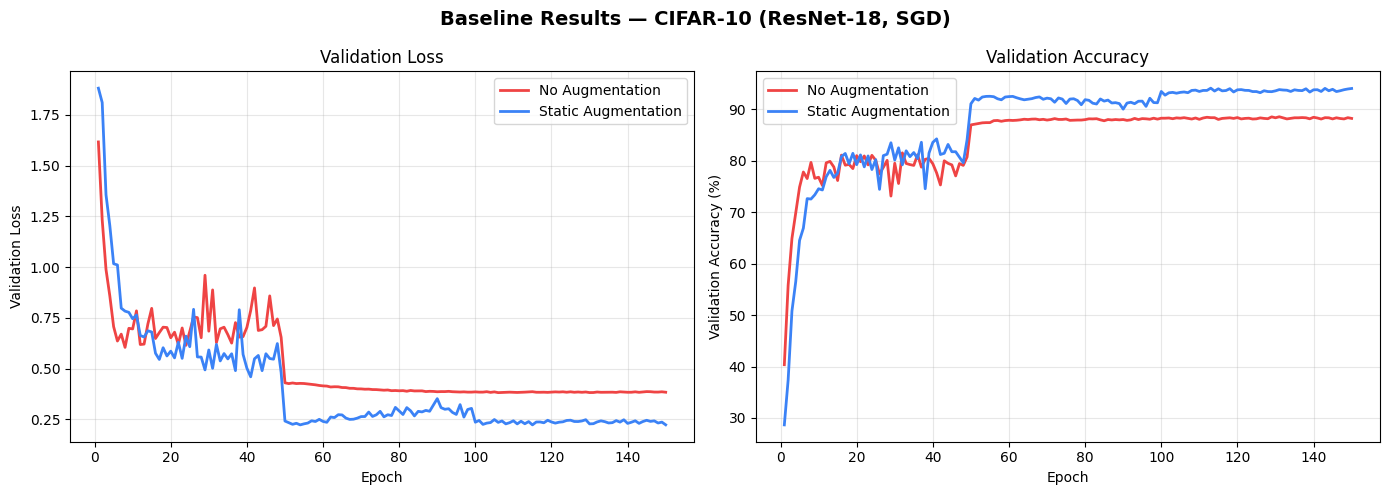

Plot 1 saved → ./checkpoints/plot1_val_comparison.png


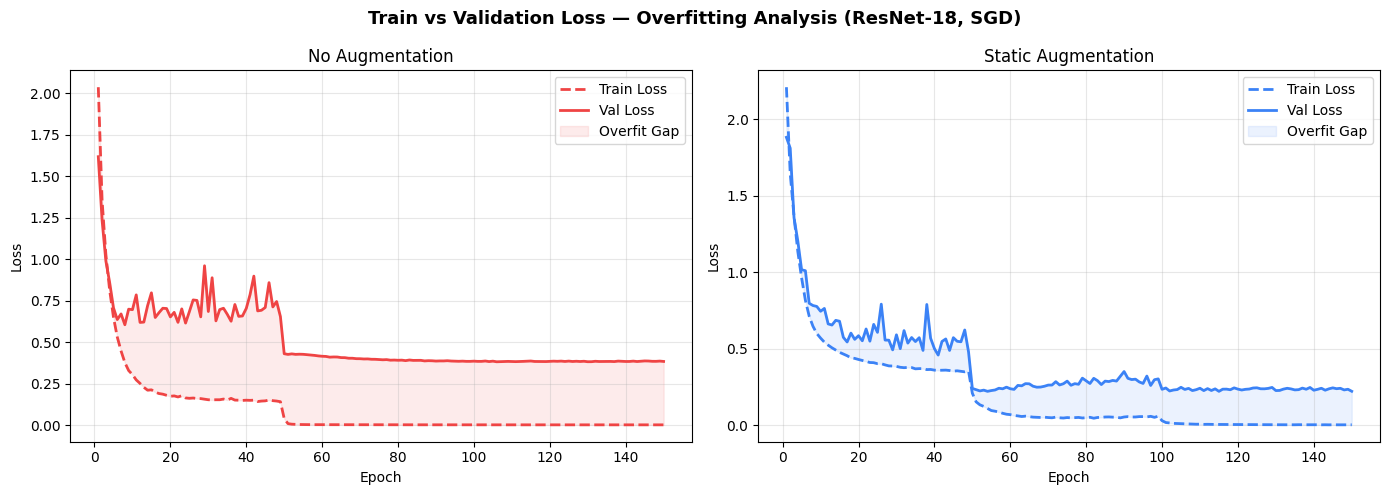

Plot 2 saved → ./checkpoints/plot2_train_vs_val_loss.png


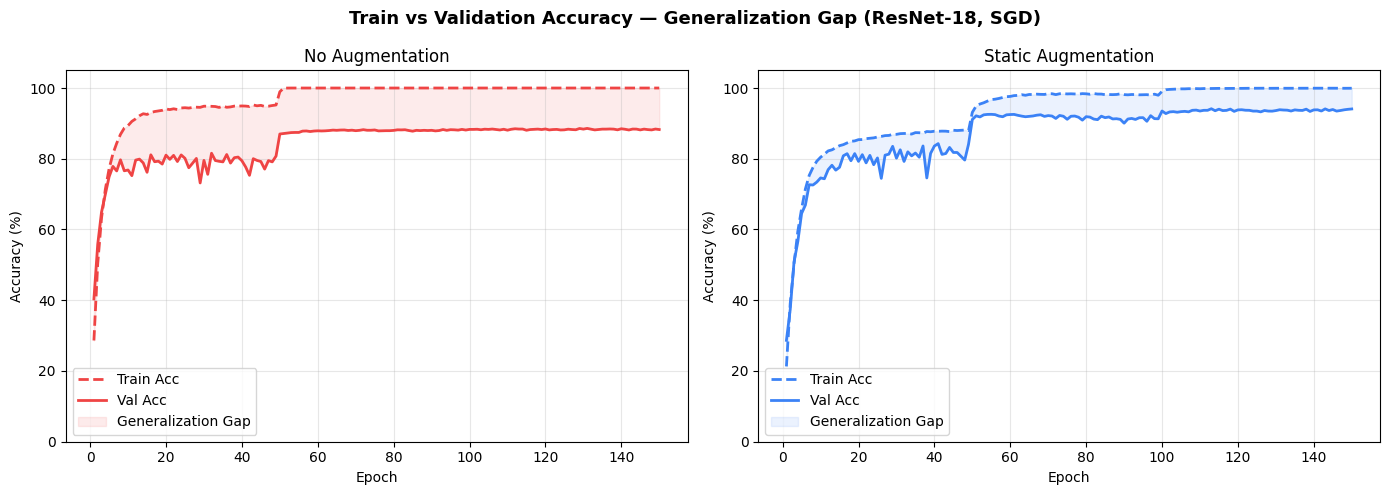

Plot 3 saved → ./checkpoints/plot3_train_vs_val_acc.png

── RESULTS SUMMARY ──────────────────────────────────────────────
Method                    Best Val  Train Acc      Gap  Epochs
-----------------------------------------------------------------
No Augmentation             88.58%    100.00%   11.42%    150
Static Augmentation         94.14%     99.94%    5.80%    150
-----------------------------------------------------------------
  Gap = Final Train Acc - Best Val Acc  (lower = better generalization)

  Augmentation reduced the overfitting gap by 5.62%
  Augmentation improved val acc by 5.56%

  Your curriculum method should beat the Static Augmentation row.


In [19]:
import torch
import matplotlib.pyplot as plt
import os

CHECKPOINT_DIR = "./checkpoints"

# ── Load histories ────────────────────────────────────────────
def load_history(name):
    path = os.path.join(CHECKPOINT_DIR, f'{name}_history.pt')
    if not os.path.exists(path):
        print(f'⚠️  Not found: {path}')
        return None
    return torch.load(path)

h_no_aug = load_history('resnet_18_cifar10_no_augmentation')
h_static  = load_history('resnet_18_cifar10_static_augmentation')

epochs_no_aug = range(1, len(h_no_aug['val_acc']) + 1)
epochs_static  = range(1, len(h_static['val_acc']) + 1)


# ════════════════════════════════════════════════════════════
#  PLOT 1 (original) — Val Loss & Val Accuracy comparison
# ════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Baseline Results — CIFAR-10 (ResNet-18, SGD)',
              fontsize=14, fontweight='bold')

axes1[0].plot(epochs_no_aug, h_no_aug['val_loss'],
              label='No Augmentation',     color='#ef4444', linewidth=2)
axes1[0].plot(epochs_static,  h_static['val_loss'],
              label='Static Augmentation', color='#3b82f6', linewidth=2)
axes1[0].set_xlabel('Epoch')
axes1[0].set_ylabel('Validation Loss')
axes1[0].set_title('Validation Loss')
axes1[0].legend()
axes1[0].grid(alpha=0.3)

axes1[1].plot(epochs_no_aug, [a * 100 for a in h_no_aug['val_acc']],
              label='No Augmentation',     color='#ef4444', linewidth=2)
axes1[1].plot(epochs_static,  [a * 100 for a in h_static['val_acc']],
              label='Static Augmentation', color='#3b82f6', linewidth=2)
axes1[1].set_xlabel('Epoch')
axes1[1].set_ylabel('Validation Accuracy (%)')
axes1[1].set_title('Validation Accuracy')
axes1[1].legend()
axes1[1].grid(alpha=0.3)

plt.tight_layout()
path1 = os.path.join(CHECKPOINT_DIR, 'plot1_val_comparison.png')
plt.savefig(path1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 1 saved → {path1}')


# ════════════════════════════════════════════════════════════
#  PLOT 2 — Train Loss vs Val Loss (overfitting analysis)
#  One subplot per experiment — shaded gap shows overfitting
# ════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Train vs Validation Loss — Overfitting Analysis (ResNet-18, SGD)',
              fontsize=13, fontweight='bold')

# No Augmentation
axes2[0].plot(epochs_no_aug, h_no_aug['train_loss'],
              label='Train Loss', color='#ef4444', linewidth=2, linestyle='--')
axes2[0].plot(epochs_no_aug, h_no_aug['val_loss'],
              label='Val Loss',   color='#ef4444', linewidth=2)
axes2[0].fill_between(epochs_no_aug,
                       h_no_aug['train_loss'], h_no_aug['val_loss'],
                       alpha=0.1, color='#ef4444', label='Overfit Gap')
axes2[0].set_xlabel('Epoch')
axes2[0].set_ylabel('Loss')
axes2[0].set_title('No Augmentation')
axes2[0].legend()
axes2[0].grid(alpha=0.3)

# Static Augmentation
axes2[1].plot(epochs_static, h_static['train_loss'],
              label='Train Loss', color='#3b82f6', linewidth=2, linestyle='--')
axes2[1].plot(epochs_static, h_static['val_loss'],
              label='Val Loss',   color='#3b82f6', linewidth=2)
axes2[1].fill_between(epochs_static,
                       h_static['train_loss'], h_static['val_loss'],
                       alpha=0.1, color='#3b82f6', label='Overfit Gap')
axes2[1].set_xlabel('Epoch')
axes2[1].set_ylabel('Loss')
axes2[1].set_title('Static Augmentation')
axes2[1].legend()
axes2[1].grid(alpha=0.3)

plt.tight_layout()
path2 = os.path.join(CHECKPOINT_DIR, 'plot2_train_vs_val_loss.png')
plt.savefig(path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 2 saved → {path2}')


# ════════════════════════════════════════════════════════════
#  PLOT 3 — Train Acc vs Val Acc (generalization gap)
#  One subplot per experiment — shaded gap shows generalization
# ════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Train vs Validation Accuracy — Generalization Gap (ResNet-18, SGD)',
              fontsize=13, fontweight='bold')

# No Augmentation
train_acc_no_aug = [a * 100 for a in h_no_aug['train_acc']]
val_acc_no_aug   = [a * 100 for a in h_no_aug['val_acc']]
axes3[0].plot(epochs_no_aug, train_acc_no_aug,
              label='Train Acc', color='#ef4444', linewidth=2, linestyle='--')
axes3[0].plot(epochs_no_aug, val_acc_no_aug,
              label='Val Acc',   color='#ef4444', linewidth=2)
axes3[0].fill_between(epochs_no_aug, val_acc_no_aug, train_acc_no_aug,
                       alpha=0.1, color='#ef4444', label='Generalization Gap')
axes3[0].set_xlabel('Epoch')
axes3[0].set_ylabel('Accuracy (%)')
axes3[0].set_title('No Augmentation')
axes3[0].set_ylim(0, 105)
axes3[0].legend()
axes3[0].grid(alpha=0.3)

# Static Augmentation
train_acc_static = [a * 100 for a in h_static['train_acc']]
val_acc_static   = [a * 100 for a in h_static['val_acc']]
axes3[1].plot(epochs_static, train_acc_static,
              label='Train Acc', color='#3b82f6', linewidth=2, linestyle='--')
axes3[1].plot(epochs_static, val_acc_static,
              label='Val Acc',   color='#3b82f6', linewidth=2)
axes3[1].fill_between(epochs_static, val_acc_static, train_acc_static,
                       alpha=0.1, color='#3b82f6', label='Generalization Gap')
axes3[1].set_xlabel('Epoch')
axes3[1].set_ylabel('Accuracy (%)')
axes3[1].set_title('Static Augmentation')
axes3[1].set_ylim(0, 105)
axes3[1].legend()
axes3[1].grid(alpha=0.3)

plt.tight_layout()
path3 = os.path.join(CHECKPOINT_DIR, 'plot3_train_vs_val_acc.png')
plt.savefig(path3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 3 saved → {path3}')


# ════════════════════════════════════════════════════════════
#  SUMMARY TABLE
# ════════════════════════════════════════════════════════════
best_no_aug        = max(h_no_aug['val_acc']) * 100
best_static        = max(h_static['val_acc']) * 100
final_train_no_aug = h_no_aug['train_acc'][-1] * 100
final_train_static = h_static['train_acc'][-1] * 100
gap_no_aug         = final_train_no_aug - best_no_aug
gap_static         = final_train_static - best_static

print('\n── RESULTS SUMMARY ──────────────────────────────────────────────')
print(f'{"Method":<24} {"Best Val":>9} {"Train Acc":>10} {"Gap":>8} {"Epochs":>7}')
print('-' * 65)
print(f'{"No Augmentation":<24} {best_no_aug:>8.2f}%  {final_train_no_aug:>8.2f}%  '
      f'{gap_no_aug:>6.2f}%  {len(h_no_aug["val_acc"]):>5}')
print(f'{"Static Augmentation":<24} {best_static:>8.2f}%  {final_train_static:>8.2f}%  '
      f'{gap_static:>6.2f}%  {len(h_static["val_acc"]):>5}')
print('-' * 65)
print(f'  Gap = Final Train Acc - Best Val Acc  (lower = better generalization)')
print(f'\n  Augmentation reduced the overfitting gap by {gap_no_aug - gap_static:.2f}%')
print(f'  Augmentation improved val acc by {best_static - best_no_aug:.2f}%')
print('\n  Your curriculum method should beat the Static Augmentation row.')

Check What's Actually in Your Drive First

In [18]:
import os
files = sorted(os.listdir(CHECKPOINT_DIR))
for f in files:
    if '_best.pth' in f:
        print(f)

cifar10_no_augmentation_best.pth
cifar10_static_augmentation_best.pth
debug_test_best.pth
resnet_18_cifar10_no_augmentation_best.pth
resnet_18_cifar10_static_augmentation_best.pth


**Resum training from latest checkpoint**

In [ ]:
# ── Resume Training from Checkpoint ──────────────────────────
import os, time
from pathlib import Path

RESUME_NAME = 'resnet_18_cifar10_static_augmentation'
EPOCHS      = 150

# Load checkpoint
ckpt_path = os.path.join(CHECKPOINT_DIR, f'{RESUME_NAME}_best.pth')
ckpt      = torch.load(ckpt_path, map_location=device)

start_epoch  = ckpt['epoch'] + 1
best_val_acc = ckpt['val_acc']
history      = ckpt['history']

print(f'✅ Loaded checkpoint')
print(f'   Resuming from epoch : {start_epoch}')
print(f'   Best val acc so far : {best_val_acc*100:.2f}%')

# Rebuild model
net = Resnet18_Baseline(num_classes=10).to(device)
net.load_state_dict(ckpt['model_state_dict'])

# Rebuild optimizer & scheduler
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.SGD(net.parameters(), lr=0.1,
                       momentum=0.9, weight_decay=5e-4, nesterov=True)
milestones = [49, 99, 124]
scheduler  = optim.lr_scheduler.MultiStepLR(
             optimizer, milestones=milestones, gamma=0.1)

# Fast-forward scheduler to correct state
for _ in range(start_epoch - 1):
    scheduler.step()

current_lr = scheduler.get_last_lr()[0]
print(f'   Current LR          : {current_lr}')

# Reload data
train_loader, val_loader, test_loader = get_loaders(
    augmentation='static', batch_size=128
)

# Resume training loop
start_time = time.time()
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(net, train_loader, optimizer, criterion)
    val_loss,   val_acc   = evaluate(net, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save history every epoch
    torch.save(history, os.path.join(CHECKPOINT_DIR, f'{RESUME_NAME}_history.pt'))

    if epoch % 10 == 0 or epoch == start_epoch:
        elapsed    = time.time() - start_time
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch [{epoch:>3}/{EPOCHS}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | '
              f'LR: {current_lr:.5f} | Time: {elapsed:.0f}s')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch':            epoch,
            'model_state_dict': net.state_dict(),
            'val_acc':          val_acc,
            'history':          history,
            'config':           ckpt['config'],
        }, ckpt_path)
        print(f'  ✅ Best saved (epoch={epoch}, val_acc={val_acc*100:.2f}%)')

# Final test evaluation
test_loss, test_acc = evaluate(net, test_loader, criterion)
total_time = time.time() - start_time

print(f'\n── FINAL RESULTS: {RESUME_NAME} ──────────────────────')
print(f'  Best Val Acc : {best_val_acc*100:.2f}%')
print(f'  Test Acc     : {test_acc*100:.2f}%')
print(f'  Total Time   : {total_time/60:.1f} minutes')